In [1]:
!pip install yfinance pandas numpy matplotlib scipy ta-lib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import yfinance as yf
import talib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from datetime import datetime
import os, sys

In [3]:
# ============================================================
# ENSEMBLE ROTATION STRATEGY — Configuration
# ============================================================
# Rick's methodology: Long-only trend following across 30 uncorrelated
# stocks/indices. Ensemble gate (3EMA) + RSI rotation + risk parity.
# "Toyota, not Ferrari" — low parametrization, boundless exits.

# 30-Stock Universe — uncorrelated sectors
UNIVERSE = [
    # US Indices
    'SPY',   # S&P 500
    'QQQ',   # NASDAQ 100
    'DIA',   # Dow 30
    # International Indices
    'EWU',   # UK (FTSE 100 proxy)
    'EWG',   # Germany (DAX proxy)
    # FANG / Mega-Cap Tech
    'META',  # Meta
    'GOOG',  # Alphabet
    'NFLX',  # Netflix
    'TSLA',  # Tesla
    'AAPL',  # Apple
    'AMZN',  # Amazon
    # Semiconductors
    'NVDA',  # Nvidia
    'SMH',   # Semiconductor ETF
    # Healthcare
    'XLV',   # Healthcare sector ETF
    'JNJ',   # Johnson & Johnson
    'UNH',   # UnitedHealth
    # Energy
    'XLE',   # Energy sector ETF
    'XOM',   # ExxonMobil
    # Financials
    'XLF',   # Financial sector ETF
    'JPM',   # JPMorgan
    # Consumer / Value
    'XLP',   # Consumer Staples ETF
    'WMT',   # Walmart
    'PG',    # Procter & Gamble
    # Industrials
    'XLI',   # Industrials ETF
    'CAT',   # Caterpillar
    # Communication
    'XLC',   # Communication Services ETF
    # Defense
    'ITA',   # Aerospace & Defense ETF
    # Infrastructure
    'IFRA',  # Infrastructure ETF
    # Real Estate
    'XLRE',  # Real Estate ETF
    # Utilities
    'XLU',   # Utilities ETF
]

# Ensemble gate parameters (low parametrization)
EMA_SHORT = 21           # Short-term EMA
EMA_MED = 50             # Medium-term EMA
EMA_LONG = 200           # Long-term trend EMA

# RSI rotation
RSI_PERIOD = 14          # RSI for momentum ranking
MOM_LOOKBACK = 63        # ~3 month momentum

# Correlation filter
CORR_LOOKBACK = 63
CORR_THRESHOLD = 0.80

# Portfolio construction
TOP_N = 8                # Max positions (of 30)
REBAL_FREQ = 'W-FRI'    # Weekly rebalance
VOL_LOOKBACK = 21        # For risk parity weights
MAX_SINGLE_WEIGHT = 0.20 # Max weight per asset

# Backtest
INIT_CASH = 1000
START_DATE = '2020-01-01'
END_DATE = None
BENCHMARK = 'SPY'

print(f"Universe: {len(UNIVERSE)} stocks across {10} sectors")
print(f"Ensemble gate: EMA({EMA_SHORT}/{EMA_MED}/{EMA_LONG})")
print(f"RSI({RSI_PERIOD}) rotation | Top {TOP_N} | {REBAL_FREQ} rebalance")
print(f"Starting capital: ${INIT_CASH:,.0f}")
print(f"Methodology: Long-only | Boundless exits | Low parametrization")

Universe: 30 stocks across 10 sectors
Ensemble gate: EMA(21/50/200)
RSI(14) rotation | Top 8 | W-FRI rebalance
Starting capital: $1,000
Methodology: Long-only | Boundless exits | Low parametrization


In [4]:
# ============================================================
# Download Data
# ============================================================
end = END_DATE or datetime.now().strftime('%Y-%m-%d')
all_tickers = list(set(UNIVERSE + [BENCHMARK]))

print(f"Downloading {len(all_tickers)} tickers from {START_DATE} to {end}...")
raw = yf.download(all_tickers, start=START_DATE, end=end, auto_adjust=True)

close = raw['Close'].dropna(how='all')

# Coverage check
coverage = close.count() / len(close) * 100
print(f"\nData coverage:")
for t in sorted(close.columns):
    c = close[t].dropna()
    pct = coverage[t]
    status = "✅" if pct >= 80 else "⚠️"
    print(f"  {status} {t:6s}: {pct:5.1f}% ({c.index[0].strftime('%Y-%m-%d')} → {c.index[-1].strftime('%Y-%m-%d')})")

# Forward fill small gaps, drop poor coverage
close = close.ffill().dropna(axis=1, thresh=int(len(close) * 0.80))
universe = [t for t in UNIVERSE if t in close.columns]
dropped = [t for t in UNIVERSE if t not in close.columns]
if dropped:
    print(f"\n⚠️ Dropped (< 80% coverage): {dropped}")

print(f"\nActive universe: {len(universe)} / {len(UNIVERSE)} assets")
print(f"Date range: {close.index[0].strftime('%Y-%m-%d')} → {close.index[-1].strftime('%Y-%m-%d')} ({len(close)} bars)")

[*********************100%***********************]  30 of 30 completed


Data coverage:
  ✅ AAPL  : 100.0% (2020-01-02 → 2026-03-20)
  ✅ AMZN  : 100.0% (2020-01-02 → 2026-03-20)
  ✅ CAT   : 100.0% (2020-01-02 → 2026-03-20)
  ✅ DIA   : 100.0% (2020-01-02 → 2026-03-20)
  ✅ EWG   : 100.0% (2020-01-02 → 2026-03-20)
  ✅ EWU   : 100.0% (2020-01-02 → 2026-03-20)
  ✅ GOOG  : 100.0% (2020-01-02 → 2026-03-20)
  ✅ IFRA  : 100.0% (2020-01-02 → 2026-03-20)
  ✅ ITA   : 100.0% (2020-01-02 → 2026-03-20)
  ✅ JNJ   : 100.0% (2020-01-02 → 2026-03-20)
  ✅ JPM   : 100.0% (2020-01-02 → 2026-03-20)
  ✅ META  : 100.0% (2020-01-02 → 2026-03-20)
  ✅ NFLX  : 100.0% (2020-01-02 → 2026-03-20)
  ✅ NVDA  : 100.0% (2020-01-02 → 2026-03-20)
  ✅ PG    : 100.0% (2020-01-02 → 2026-03-20)
  ✅ QQQ   : 100.0% (2020-01-02 → 2026-03-20)
  ✅ SMH   : 100.0% (2020-01-02 → 2026-03-20)
  ✅ SPY   : 100.0% (2020-01-02 → 2026-03-20)
  ✅ TSLA  : 100.0% (2020-01-02 → 2026-03-20)
  ✅ UNH   : 100.0% (2020-01-02 → 2026-03-20)
  ✅ WMT   : 100.0% (2020-01-02 → 2026-03-20)
  ✅ XLC   : 100.0% (2020-01-02 → 2026-0

In [5]:
# ============================================================
# Ensemble Trend Gate + RSI Momentum
# ============================================================
# 3EMA ensemble: binary up/down for each asset
# Bullish = price > EMA_short AND EMA_short > EMA_med AND EMA_med > EMA_long
# This gives a "boundless" trend signal — stays on until trend breaks

ema_short = pd.DataFrame(index=close.index)
ema_med = pd.DataFrame(index=close.index)
ema_long = pd.DataFrame(index=close.index)
rsi = pd.DataFrame(index=close.index)
momentum = pd.DataFrame(index=close.index)

for t in universe:
    c = close[t].dropna()
    ema_short[t] = talib.EMA(c, timeperiod=EMA_SHORT)
    ema_med[t] = talib.EMA(c, timeperiod=EMA_MED)
    ema_long[t] = talib.EMA(c, timeperiod=EMA_LONG)
    rsi[t] = talib.RSI(c, timeperiod=RSI_PERIOD)
    momentum[t] = c.pct_change(MOM_LOOKBACK)

# Ensemble gate: all three EMAs aligned bullish
ensemble_gate = (
    (close[universe] > ema_short[universe]) &
    (ema_short[universe] > ema_med[universe]) &
    (ema_med[universe] > ema_long[universe])
).astype(int)

print("Ensemble trend gate (3EMA alignment):")
print(f"  EMA({EMA_SHORT}) > EMA({EMA_MED}) > EMA({EMA_LONG}) + price above all")
print(f"\nGate pass rate (% of days in uptrend):")
sectors = {
    'Indices': ['SPY', 'QQQ', 'DIA', 'EWU', 'EWG'],
    'Tech/FANG': ['META', 'GOOG', 'NFLX', 'TSLA', 'AAPL', 'AMZN', 'NVDA', 'SMH'],
    'Healthcare': ['XLV', 'JNJ', 'UNH'],
    'Energy': ['XLE', 'XOM'],
    'Financials': ['XLF', 'JPM'],
    'Consumer': ['XLP', 'WMT', 'PG'],
    'Industrials': ['XLI', 'CAT'],
    'Other': ['XLC', 'ITA', 'IFRA', 'XLRE', 'XLU'],
}
for sector, tickers in sectors.items():
    active = [t for t in tickers if t in universe]
    if active:
        rates = [ensemble_gate[t].mean() * 100 for t in active]
        avg = np.mean(rates)
        print(f"  {sector:12s}: {avg:5.1f}% avg  ({', '.join(f'{t}:{r:.0f}%' for t, r in zip(active, rates))})")

Ensemble trend gate (3EMA alignment):
  EMA(21) > EMA(50) > EMA(200) + price above all

Gate pass rate (% of days in uptrend):
  Indices     :  45.9% avg  (SPY:51%, QQQ:46%, DIA:49%, EWU:46%, EWG:38%)
  Tech/FANG   :  37.8% avg  (META:37%, GOOG:42%, NFLX:37%, TSLA:30%, AAPL:37%, AMZN:32%, NVDA:43%, SMH:44%)
  Healthcare  :  33.4% avg  (XLV:38%, JNJ:33%, UNH:29%)
  Energy      :  39.6% avg  (XLE:40%, XOM:40%)
  Financials  :  43.6% avg  (XLF:43%, JPM:44%)
  Consumer    :  38.6% avg  (XLP:39%, WMT:46%, PG:31%)
  Industrials :  43.7% avg  (XLI:46%, CAT:41%)
  Other       :  41.3% avg  (XLC:46%, ITA:45%, IFRA:45%, XLRE:33%, XLU:37%)


## Strategy Logic — Rick's Methodology

**"Toyota, not Ferrari"** — Simple, consistent, low parametrization.

### Ensemble Trend Gate (3EMA)
Binary up/down filter. Asset is "ON" when:
- Price > EMA(21) > EMA(50) > EMA(200)

**Boundless exits**: No fixed target. Stay in the trade until the EMA stack breaks.
This lets winners ride indefinitely — the key insight.

### RSI Rotation
Each rebalance, rank all "ON" assets by RSI momentum.
Select top N with lowest cross-correlation → always positioned in the
strongest, most uncorrelated trends.

### Risk Parity Weighting
Weight inversely proportional to volatility — lower-vol assets get more weight.
This stabilizes the portfolio and improves Sharpe.

### Power Law + Diversification
30 stocks across 10 sectors. When tech mean-reverts, healthcare/energy/value
step up. You don't need to time regimes — the rotation does it automatically.

### Long-Only
Markets go up more than down. Always bet on the right side of history.

In [6]:
# ============================================================
# Rotation Engine
# ============================================================
def composite_score(rsi_row, mom_row):
    """Rank by RSI + momentum (equal weight)."""
    r = rsi_row.dropna()
    m = mom_row.reindex(r.index).dropna()
    common = r.index.intersection(m.index)
    if len(common) < 2:
        return pd.Series(dtype=float)
    r, m = r[common], m[common]
    r_norm = (r - r.min()) / (r.max() - r.min() + 1e-10)
    m_norm = (m - m.min()) / (m.max() - m.min() + 1e-10)
    return 0.5 * r_norm + 0.5 * m_norm

def correlation_filter(candidates, corr_matrix, threshold):
    """Keep highest-ranked, drop highly correlated duplicates."""
    selected = []
    for asset in candidates:
        if not selected:
            selected.append(asset)
            continue
        try:
            max_corr = max(abs(corr_matrix.loc[asset, s]) for s in selected)
        except KeyError:
            selected.append(asset)
            continue
        if max_corr < threshold:
            selected.append(asset)
    return selected

def risk_parity_weights(selected, vol_series, max_weight):
    """Inverse-volatility weighting with cap."""
    if not selected:
        return {}
    vols = vol_series.reindex(selected).replace(0, np.nan).dropna()
    if len(vols) == 0:
        return {s: 1.0/len(selected) for s in selected}
    inv_vol = 1.0 / vols
    w = inv_vol / inv_vol.sum()
    w = w.clip(upper=max_weight)
    w = w / w.sum()
    return w.to_dict()

# Daily returns
daily_rets = close[universe].pct_change()

# Rebalance schedule
warmup = max(EMA_LONG, MOM_LOOKBACK, CORR_LOOKBACK, VOL_LOOKBACK) + 10
rebal_dates = close.resample(REBAL_FREQ).last().index
rebal_dates = rebal_dates[(rebal_dates >= close.index[warmup]) & (rebal_dates <= close.index[-1])]

print(f"Rebalance dates: {len(rebal_dates)}")
print(f"  First: {rebal_dates[0].strftime('%Y-%m-%d')}")
print(f"  Last:  {rebal_dates[-1].strftime('%Y-%m-%d')}")

# Run rotation
holdings_history = {}
log = []

for dt in rebal_dates:
    idx = close.index.get_indexer([dt], method='ffill')[0]
    if idx < 0:
        continue
    
    # 1. Ensemble gate — only assets in confirmed uptrend
    gate = ensemble_gate.iloc[idx]
    candidates = [t for t in universe if gate.get(t, 0) == 1]
    
    if len(candidates) < 2:
        holdings_history[close.index[idx]] = {}
        log.append({'date': close.index[idx], 'n_pass_gate': len(candidates),
                     'n_held': 0, 'holdings': 'CASH'})
        continue
    
    # 2. Rank by composite score (RSI + momentum)
    scores = composite_score(rsi.iloc[idx][candidates], momentum.iloc[idx][candidates])
    if len(scores) < 2:
        holdings_history[close.index[idx]] = {}
        log.append({'date': close.index[idx], 'n_pass_gate': len(candidates),
                     'n_held': 0, 'holdings': 'CASH'})
        continue
    ranked = scores.sort_values(ascending=False).index.tolist()
    
    # 3. Correlation filter
    corr_window = daily_rets[ranked].iloc[max(0, idx-CORR_LOOKBACK):idx]
    corr_mat = corr_window.corr()
    filtered = correlation_filter(ranked, corr_mat, CORR_THRESHOLD)
    
    # 4. Select top N
    selected = filtered[:TOP_N]
    
    # 5. Risk parity weights
    vol_window = daily_rets[selected].iloc[max(0, idx-VOL_LOOKBACK):idx]
    realized_vol = vol_window.std() * np.sqrt(252)
    weights = risk_parity_weights(selected, realized_vol, MAX_SINGLE_WEIGHT)
    
    holdings_history[close.index[idx]] = weights
    log.append({
        'date': close.index[idx],
        'n_pass_gate': len(candidates),
        'n_held': len(selected),
        'holdings': ', '.join(f"{t}({w:.0%})" for t, w in weights.items())
    })

log_df = pd.DataFrame(log)
print(f"\nRotation summary:")
print(f"  Total rebalances: {len(log_df)}")
print(f"  Avg holdings: {log_df['n_held'].mean():.1f} / {TOP_N}")
print(f"  Avg passing gate: {log_df['n_pass_gate'].mean():.1f} / {len(universe)}")
print(f"  Cash periods: {(log_df['n_held'] == 0).sum()} ({(log_df['n_held'] == 0).mean():.1%})")
print(f"\nLast 5 rebalances:")
for _, r in log_df.tail(5).iterrows():
    print(f"  {r['date'].strftime('%Y-%m-%d')}: {r['n_held']} held ({r['n_pass_gate']} passed gate) → {r['holdings']}")

Rebalance dates: 282
  First: 2020-10-30
  Last:  2026-03-20

Rotation summary:
  Total rebalances: 282
  Avg holdings: 6.5 / 8
  Avg passing gate: 13.9 / 30
  Cash periods: 10 (3.5%)

Last 5 rebalances:
  2026-02-20: 8 held (18 passed gate) → CAT(6%), JNJ(20%), XLE(10%), IFRA(16%), ITA(11%), EWU(14%), XLP(17%), SMH(7%)
  2026-02-27: 8 held (16 passed gate) → XLE(9%), JNJ(15%), XLU(13%), PG(12%), XLP(14%), EWU(13%), XLI(14%), ITA(10%)
  2026-03-06: 4 held (5 passed gate) → XLE(26%), ITA(22%), XLU(26%), XLC(26%)
  2026-03-13: 4 held (5 passed gate) → XLE(26%), XLU(26%), JNJ(26%), WMT(21%)
  2026-03-20: 1 held (2 passed gate) → XLE(100%)


In [7]:
# ============================================================
# Simulate Portfolio
# ============================================================
portfolio_value = pd.Series(dtype=float, index=close.index)
portfolio_value.iloc[0] = INIT_CASH
daily_n_holdings = pd.Series(0, index=close.index, dtype=int)

current_weights = {}
rebal_set = set(holdings_history.keys())

for i in range(1, len(close)):
    dt = close.index[i]
    prev_dt = close.index[i-1]
    
    # Update weights on rebalance
    if dt in rebal_set:
        current_weights = holdings_history[dt]
    elif prev_dt in rebal_set:
        current_weights = holdings_history[prev_dt]
    
    # Daily return
    if current_weights:
        port_ret = sum(
            w * daily_rets[t].iloc[i]
            for t, w in current_weights.items()
            if pd.notna(daily_rets[t].iloc[i])
        )
        # Transaction cost on rebalance days (~10bps round-trip)
        if dt in rebal_set or prev_dt in rebal_set:
            port_ret -= 0.001
    else:
        port_ret = 0.0
    
    portfolio_value.iloc[i] = portfolio_value.iloc[i-1] * (1 + port_ret)
    daily_n_holdings.iloc[i] = len(current_weights)

portfolio_value = portfolio_value.dropna()

# Benchmark
bench_rets = close[BENCHMARK].pct_change()
bench_value = INIT_CASH * (1 + bench_rets).cumprod()
bench_value = bench_value.reindex(portfolio_value.index).ffill()

port_rets = portfolio_value.pct_change().dropna()

print(f"Simulation complete: {len(portfolio_value)} days")
print(f"Final value: ${portfolio_value.iloc[-1]:,.2f} (started at ${INIT_CASH:,.0f})")
print(f"Benchmark ({BENCHMARK}): ${bench_value.iloc[-1]:,.2f}")

Simulation complete: 1562 days
Final value: $3,616.99 (started at $1,000)
Benchmark (SPY): $2,184.56


In [8]:
# ============================================================
# Performance Metrics
# ============================================================
def calc_metrics(returns, name):
    total_ret = (1 + returns).prod() - 1
    n_years = len(returns) / 252
    ann_ret = (1 + total_ret) ** (1/max(n_years, 0.01)) - 1
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    downside = returns[returns < 0].std() * np.sqrt(252)
    sortino = ann_ret / downside if downside > 0 else 0
    cum = (1 + returns).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    win_rate = (returns > 0).mean()
    return {
        'Name': name, 'Total Return': total_ret, 'Ann. Return': ann_ret,
        'Ann. Volatility': ann_vol, 'Sharpe': sharpe, 'Sortino': sortino,
        'Max Drawdown': max_dd, 'Calmar': calmar, 'Win Rate': win_rate,
    }

strat = calc_metrics(port_rets, "Ensemble Rotation")
bench = calc_metrics(bench_rets.reindex(port_rets.index).dropna(), f"{BENCHMARK} B&H")

print("=" * 65)
print("PERFORMANCE COMPARISON")
print("=" * 65)
print(f"{'Metric':<20} {'Ensemble Rotation':>18} {BENCHMARK + ' B&H':>18}")
print("-" * 65)
for key in ['Total Return', 'Ann. Return', 'Ann. Volatility', 'Sharpe', 'Sortino', 'Max Drawdown', 'Calmar', 'Win Rate']:
    sv = strat[key]
    bv = bench[key]
    if key in ['Sharpe', 'Sortino', 'Calmar']:
        print(f"{key:<20} {sv:>18.2f} {bv:>18.2f}")
    else:
        print(f"{key:<20} {sv:>18.1%} {bv:>18.1%}")

PERFORMANCE COMPARISON
Metric                Ensemble Rotation            SPY B&H
-----------------------------------------------------------------
Total Return                     261.7%             118.5%
Ann. Return                       23.1%              13.4%
Ann. Volatility                   13.7%              20.5%
Sharpe                             1.68               0.66
Sortino                            2.08               0.81
Max Drawdown                     -21.3%             -33.7%
Calmar                             1.08               0.40
Win Rate                          45.9%              54.8%


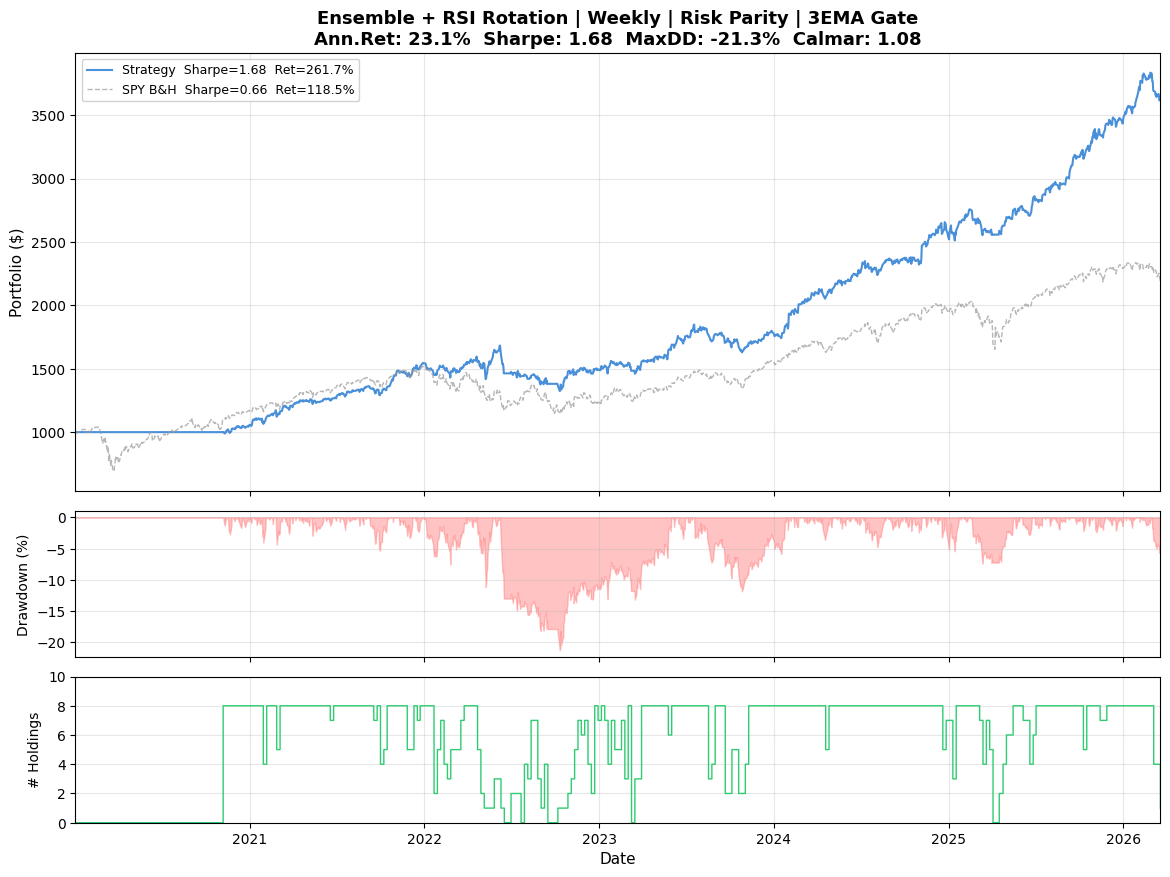

In [9]:
# ============================================================
# Performance Dashboard — Rick's 3-Panel Style
# ============================================================
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.08)

STRAT_COLOR = '#4A90D9'
BENCH_COLOR = '#999999'
DD_COLOR = '#FF6B6B'
HOLD_COLOR = '#2ECC71'

s = strat  # shorthand
b = bench

# --- Panel 1: Equity curve ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(portfolio_value.index, portfolio_value.values, color=STRAT_COLOR, linewidth=1.5,
         label=f'Strategy  Sharpe={s["Sharpe"]:.2f}  Ret={s["Total Return"]:.1%}')
ax1.plot(bench_value.index, bench_value.values, color=BENCH_COLOR, linewidth=1, linestyle='--', alpha=0.7,
         label=f'{BENCHMARK} B&H  Sharpe={b["Sharpe"]:.2f}  Ret={b["Total Return"]:.1%}')
ax1.set_ylabel('Portfolio ($)', fontsize=11)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(portfolio_value.index[0], portfolio_value.index[-1])
ax1.tick_params(labelbottom=False)
ax1.set_title(
    f"Ensemble + RSI Rotation | Weekly | Risk Parity | 3EMA Gate\n"
    f"Ann.Ret: {s['Ann. Return']:.1%}  Sharpe: {s['Sharpe']:.2f}  MaxDD: {s['Max Drawdown']:.1%}  Calmar: {s['Calmar']:.2f}",
    fontsize=13, fontweight='bold'
)

# --- Panel 2: Drawdown ---
ax2 = fig.add_subplot(gs[1], sharex=ax1)
cum = (1 + port_rets).cumprod()
dd = ((cum - cum.cummax()) / cum.cummax()) * 100
ax2.fill_between(dd.index, dd.values, 0, color=DD_COLOR, alpha=0.4)
ax2.set_ylabel('Drawdown (%)', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.tick_params(labelbottom=False)

# --- Panel 3: Number of holdings ---
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.step(daily_n_holdings.index, daily_n_holdings.values, where='post', color=HOLD_COLOR, linewidth=1.0)
ax3.set_ylabel('# Holdings', fontsize=10)
ax3.set_xlabel('Date', fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, TOP_N + 2)

plt.tight_layout()
plt.show()

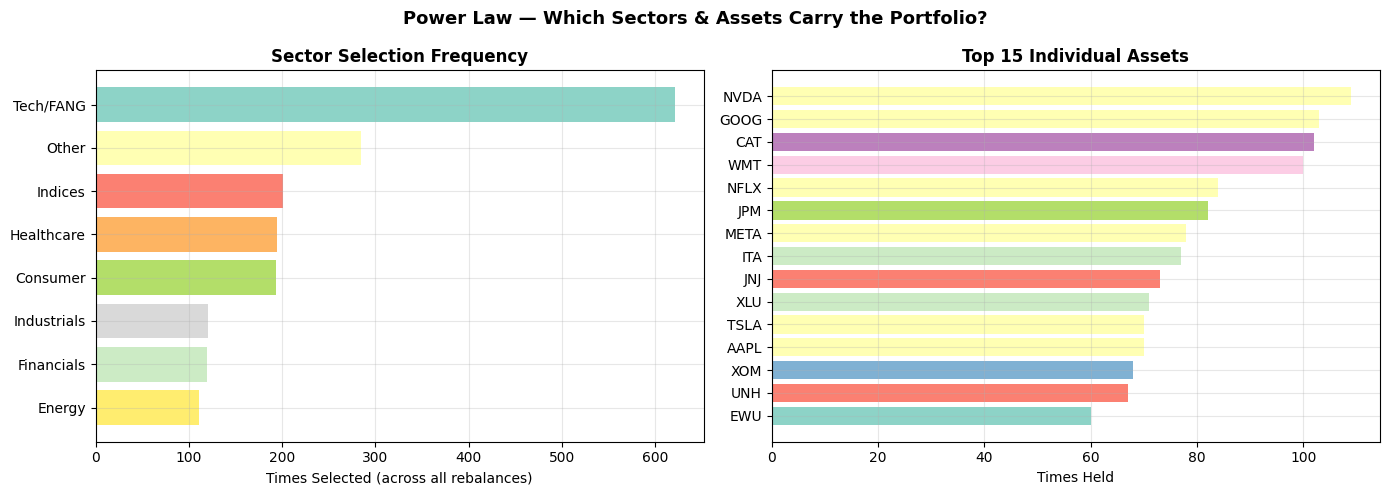

Sector breakdown:
  Tech/FANG     : 621 (33.7%)
  Other         : 285 (15.4%)
  Indices       : 201 (10.9%)
  Healthcare    : 194 (10.5%)
  Consumer      : 193 (10.5%)
  Industrials   : 121 (6.6%)
  Financials    : 119 (6.4%)
  Energy        : 111 (6.0%)


In [10]:
# ============================================================
# Sector Contribution — Power Law in Action
# ============================================================
sector_map = {}
for sector, tickers in sectors.items():
    for t in tickers:
        if t in universe:
            sector_map[t] = sector

# Count holdings by sector over time
sector_hold_counts = {}
for dt, weights in holdings_history.items():
    for t in weights:
        sec = sector_map.get(t, 'Other')
        sector_hold_counts[sec] = sector_hold_counts.get(sec, 0) + 1

if sector_hold_counts:
    sec_df = pd.DataFrame([
        {'Sector': s, 'Times Selected': c}
        for s, c in sorted(sector_hold_counts.items(), key=lambda x: -x[1])
    ])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Sector selection frequency
    colors = plt.cm.Set3(np.linspace(0, 1, len(sec_df)))
    axes[0].barh(sec_df['Sector'], sec_df['Times Selected'], color=colors)
    axes[0].set_xlabel('Times Selected (across all rebalances)')
    axes[0].set_title('Sector Selection Frequency', fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3)
    
    # Individual asset frequency
    hold_counts = {}
    for dt, weights in holdings_history.items():
        for t in weights:
            hold_counts[t] = hold_counts.get(t, 0) + 1
    
    asset_df = pd.DataFrame([
        {'Asset': t, 'Count': c, 'Sector': sector_map.get(t, '?')}
        for t, c in sorted(hold_counts.items(), key=lambda x: -x[1])
    ]).head(15)  # Top 15
    
    bar_colors = [plt.cm.Set3(list(sectors.keys()).index(s) / len(sectors)) 
                  if s in sectors else '#999' for s in asset_df['Sector']]
    axes[1].barh(asset_df['Asset'], asset_df['Count'], color=bar_colors)
    axes[1].set_xlabel('Times Held')
    axes[1].set_title('Top 15 Individual Assets', fontweight='bold')
    axes[1].invert_yaxis()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('Power Law — Which Sectors & Assets Carry the Portfolio?', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Sector breakdown:")
    total = sec_df['Times Selected'].sum()
    for _, r in sec_df.iterrows():
        print(f"  {r['Sector']:14s}: {r['Times Selected']:3d} ({r['Times Selected']/total:.1%})")

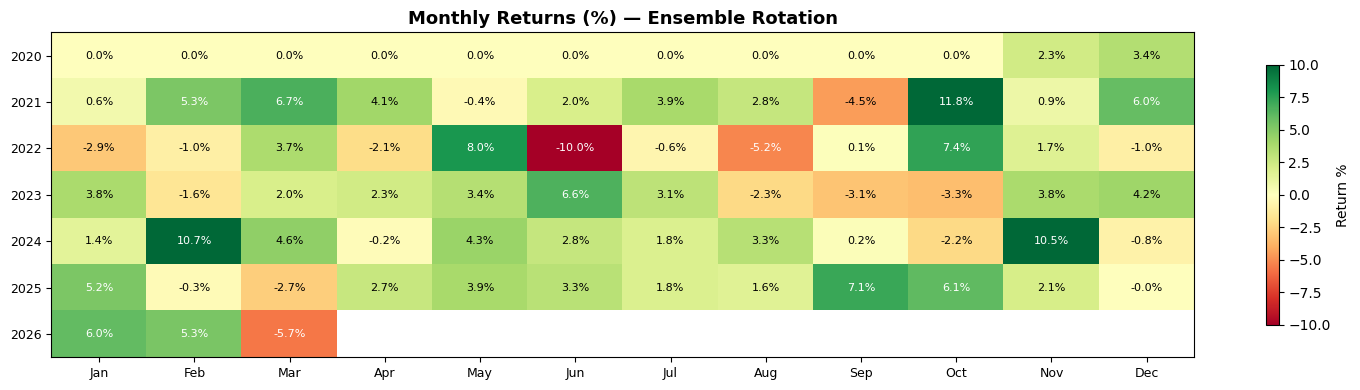

Yearly returns:
  2020: +5.8%
  2021: +45.8%
  2022: -3.2%
  2023: +19.9%
  2024: +42.1%
  2025: +35.0%
  2026: +5.3%


In [11]:
# ============================================================
# Monthly Returns Heatmap
# ============================================================
monthly = port_rets.resample('ME').apply(lambda x: (1+x).prod() - 1)
monthly_df = pd.DataFrame({
    'Year': monthly.index.year, 'Month': monthly.index.month, 'Return': monthly.values
})
pivot = monthly_df.pivot_table(values='Return', index='Year', columns='Month', aggfunc='first')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Add yearly total
pivot['Year Total'] = pivot.apply(lambda r: (1 + r.dropna()).prod() - 1, axis=1)

fig, ax = plt.subplots(figsize=(15, 4))
# Just the monthly part (not Year Total) for heatmap
monthly_vals = pivot.iloc[:, :12]
im = ax.imshow(monthly_vals.values * 100, cmap='RdYlGn', aspect='auto', vmin=-10, vmax=10)

ax.set_xticks(range(len(monthly_vals.columns)))
ax.set_xticklabels(monthly_vals.columns, fontsize=9)
ax.set_yticks(range(len(monthly_vals.index)))
ax.set_yticklabels(monthly_vals.index, fontsize=9)

for i in range(len(monthly_vals.index)):
    for j in range(len(monthly_vals.columns)):
        val = monthly_vals.values[i, j]
        if not np.isnan(val):
            color = 'white' if abs(val) > 0.05 else 'black'
            ax.text(j, i, f'{val*100:.1f}%', ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, label='Return %', shrink=0.8)
ax.set_title('Monthly Returns (%) — Ensemble Rotation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print yearly summary
print("Yearly returns:")
for yr, ret in pivot['Year Total'].items():
    print(f"  {yr}: {ret:+.1%}")

In [12]:
# ============================================================
# Trade Log
# ============================================================
trades = []
prev_holdings = set()

for dt, weights in sorted(holdings_history.items()):
    curr = set(weights.keys())
    for t in curr - prev_holdings:
        trades.append({'Date': dt, 'Asset': t, 'Action': 'BUY', 'Weight': f"{weights[t]:.1%}"})
    for t in prev_holdings - curr:
        trades.append({'Date': dt, 'Asset': t, 'Action': 'SELL', 'Weight': '-'})
    prev_holdings = curr

trades_df = pd.DataFrame(trades)
n_buys = (trades_df['Action'] == 'BUY').sum()
n_sells = (trades_df['Action'] == 'SELL').sum()

print(f"Total trades: {len(trades_df)} ({n_buys} buys, {n_sells} sells)")
print(f"Avg trades/rebalance: {len(trades_df)/len(rebal_dates):.1f}")
print(f"Turnover: {n_buys/len(rebal_dates):.1f} new positions per week")
print(f"\nLast 20 trades:")
print(trades_df.tail(20).to_string(index=False))

Total trades: 1309 (655 buys, 654 sells)
Avg trades/rebalance: 4.6
Turnover: 2.3 new positions per week

Last 20 trades:
      Date Asset Action Weight
2026-02-20  XLRE   SELL      -
2026-02-27   XLU    BUY  12.8%
2026-02-27    PG    BUY  12.0%
2026-02-27   XLI    BUY  13.9%
2026-02-27   SMH   SELL      -
2026-02-27  IFRA   SELL      -
2026-02-27   CAT   SELL      -
2026-03-06   XLC    BUY  26.0%
2026-03-06   JNJ   SELL      -
2026-03-06   XLP   SELL      -
2026-03-06   EWU   SELL      -
2026-03-06   XLI   SELL      -
2026-03-06    PG   SELL      -
2026-03-13   JNJ    BUY  26.2%
2026-03-13   WMT    BUY  21.3%
2026-03-13   XLC   SELL      -
2026-03-13   ITA   SELL      -
2026-03-20   XLU   SELL      -
2026-03-20   JNJ   SELL      -
2026-03-20   WMT   SELL      -


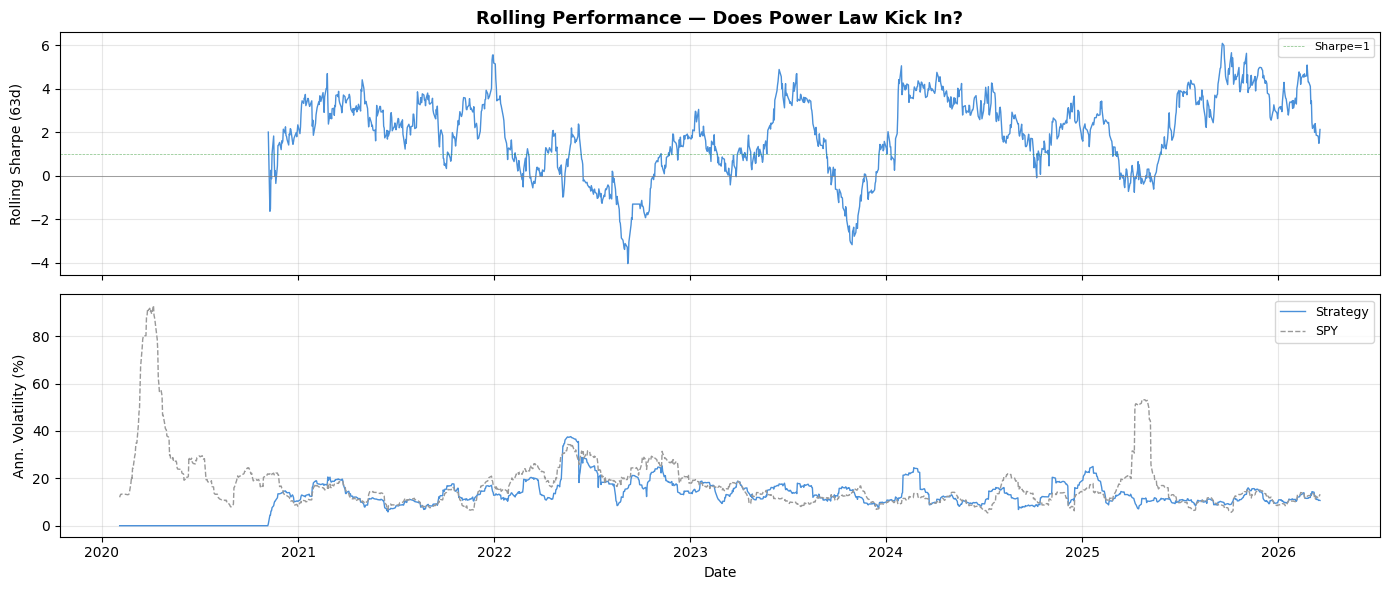

In [13]:
# ============================================================
# Rolling Performance
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Rolling Sharpe (63-day)
roll_sharpe = port_rets.rolling(63).mean() / port_rets.rolling(63).std() * np.sqrt(252)
axes[0].plot(roll_sharpe.index, roll_sharpe.values, color=STRAT_COLOR, linewidth=1)
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axhline(1, color='green', linewidth=0.5, linestyle='--', alpha=0.5, label='Sharpe=1')
axes[0].set_ylabel('Rolling Sharpe (63d)')
axes[0].set_title('Rolling Performance — Does Power Law Kick In?', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Rolling vol comparison
roll_vol = port_rets.rolling(21).std() * np.sqrt(252) * 100
bench_roll_vol = bench_rets.reindex(port_rets.index).rolling(21).std() * np.sqrt(252) * 100
axes[1].plot(roll_vol.index, roll_vol.values, color=STRAT_COLOR, linewidth=1, label='Strategy')
axes[1].plot(bench_roll_vol.dropna().index, bench_roll_vol.dropna().values,
             color=BENCH_COLOR, linewidth=1, linestyle='--', label=BENCHMARK)
axes[1].set_ylabel('Ann. Volatility (%)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

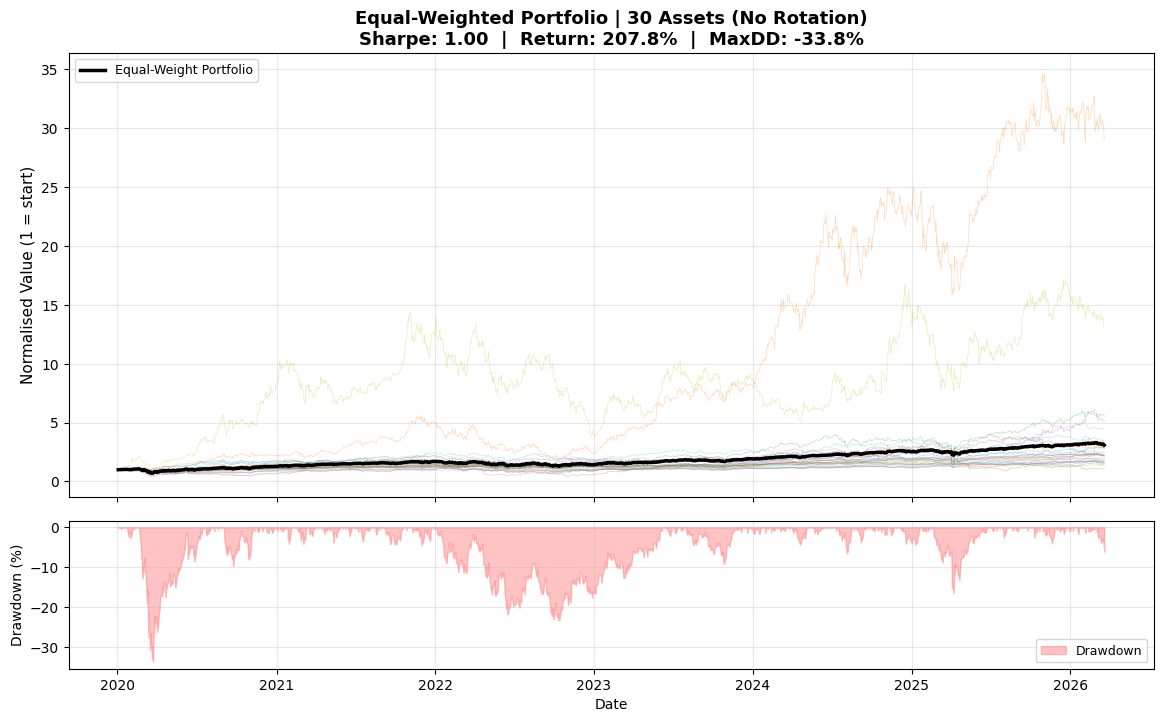


ROTATION vs EQUAL-WEIGHT COMPARISON
Metric                     Rotation   Equal-Weight
-------------------------------------------------------
Sharpe                         1.68           1.00
Total Return                 261.7%         207.8%
Max Drawdown                 -21.3%         -33.8%
Calmar                         1.08           0.59


In [14]:
# ============================================================
# Equal-Weight Baseline — The "Before" Chart
# ============================================================
ew_rets = daily_rets[universe].mean(axis=1)
ew_cum = INIT_CASH * (1 + ew_rets).cumprod()

fig = plt.figure(figsize=(14, 8))
gs2 = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)

ax1 = fig.add_subplot(gs2[0])

# Individual assets (faded)
for t in universe:
    norm = close[t] / close[t].dropna().iloc[0]
    ax1.plot(close.index, norm, linewidth=0.5, alpha=0.3)

# Equal-weight (bold black)
ew_norm = ew_cum / INIT_CASH
ax1.plot(ew_norm.index, ew_norm.values, color='black', linewidth=2.5, label='Equal-Weight Portfolio')

ew_sharpe = (ew_rets.mean() / ew_rets.std()) * np.sqrt(252)
ew_total = (1 + ew_rets).prod() - 1
ew_dd = ((1 + ew_rets).cumprod() / (1 + ew_rets).cumprod().cummax() - 1).min()

ax1.set_ylabel('Normalised Value (1 = start)', fontsize=11)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_title(
    f"Equal-Weighted Portfolio | {len(universe)} Assets (No Rotation)\n"
    f"Sharpe: {ew_sharpe:.2f}  |  Return: {ew_total:.1%}  |  MaxDD: {ew_dd:.1%}",
    fontsize=13, fontweight='bold'
)
ax1.tick_params(labelbottom=False)

ax2 = fig.add_subplot(gs2[1], sharex=ax1)
ew_dd_series = ((1 + ew_rets).cumprod() / (1 + ew_rets).cumprod().cummax() - 1) * 100
ax2.fill_between(ew_dd_series.index, ew_dd_series.values, 0, color=DD_COLOR, alpha=0.4, label='Drawdown')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparison table
print(f"\n{'='*55}")
print(f"ROTATION vs EQUAL-WEIGHT COMPARISON")
print(f"{'='*55}")
print(f"{'Metric':<20} {'Rotation':>14} {'Equal-Weight':>14}")
print(f"{'-'*55}")
print(f"{'Sharpe':<20} {s['Sharpe']:>14.2f} {ew_sharpe:>14.2f}")
print(f"{'Total Return':<20} {s['Total Return']:>14.1%} {ew_total:>14.1%}")
print(f"{'Max Drawdown':<20} {s['Max Drawdown']:>14.1%} {ew_dd:>14.1%}")
print(f"{'Calmar':<20} {s['Calmar']:>14.2f} {(((1+ew_total)**(1/(len(ew_rets)/252))-1)/abs(ew_dd)):>14.2f}")

In [15]:
# ============================================================
# Log to Google Sheets
# ============================================================
try:
    sys.path.insert(0, os.path.join(os.getcwd(), 'lib'))
    from sheets_logger import SheetsLogger
    
    logger = SheetsLogger()
    logger.log_portfolio(
        strategy='Ensemble_Rotation',
        universe_size=len(universe),
        top_n=TOP_N,
        rebalance_freq=REBAL_FREQ,
        lookback_months=MOM_LOOKBACK // 21,
        total_return=s['Total Return'],
        ann_return=s['Ann. Return'],
        sharpe=s['Sharpe'],
        sortino=s['Sortino'],
        max_dd=s['Max Drawdown'],
        volatility=s['Ann. Volatility'],
        calmar=s['Calmar'],
        total_trades=len(trades_df),
        win_rate=s['Win Rate'],
        current_holdings=', '.join(current_weights.keys()) if current_weights else 'CASH',
        data_start=START_DATE,
        data_end=end,
        notes=f"3EMA({EMA_SHORT}/{EMA_MED}/{EMA_LONG}) RSI({RSI_PERIOD}) Mom({MOM_LOOKBACK}d) Corr<{CORR_THRESHOLD} RP Top{TOP_N}"
    )
    print("✅ Results logged to Google Sheets")
except Exception as e:
    print(f"⚠️ Sheets logging skipped: {e}")
    print("(Run in Colab to enable)")

⚠️ Sheets logging skipped: No module named 'sheets_logger'
(Run in Colab to enable)


In [16]:
# ============================================================
# Current Portfolio State
# ============================================================
print("=" * 65)
print("CURRENT PORTFOLIO STATE")
print("=" * 65)

latest_date = close.index[-1].strftime('%Y-%m-%d')

if current_weights:
    print(f"\nActive holdings ({len(current_weights)} positions) as of {latest_date}:")
    final_value = portfolio_value.iloc[-1]
    for t, w in sorted(current_weights.items(), key=lambda x: -x[1]):
        dollar = final_value * w
        sector = sector_map.get(t, '?')
        print(f"  {t:6s} ({sector:12s}): {w:6.1%} → ${dollar:>8,.2f}")
    print(f"\n  Total: ${final_value:,.2f}")
else:
    print(f"\nCurrently in CASH as of {latest_date}")

# Gate status by sector
print(f"\nEnsemble Gate Status ({latest_date}):")
for sector, tickers in sectors.items():
    active = [t for t in tickers if t in universe]
    if active:
        statuses = []
        for t in active:
            try:
                gate_val = ensemble_gate[t].iloc[-1]
                statuses.append(f"{'\u2705' if gate_val else '\u274c'}{t}")
            except:
                statuses.append(f"?{t}")
        print(f"  {sector:14s}: {' '.join(statuses)}")

print(f"\nPortfolio: ${portfolio_value.iloc[-1]:,.2f} (started at ${INIT_CASH:,.0f})")
gain = (portfolio_value.iloc[-1] / INIT_CASH - 1) * 100
print(f"Total gain: {gain:+.1f}%")

CURRENT PORTFOLIO STATE

Active holdings (1 positions) as of 2026-03-20:
  XLE    (Energy      ): 100.0% → $3,616.99

  Total: $3,616.99

Ensemble Gate Status (2026-03-20):
  Indices       : ❌SPY ❌QQQ ❌DIA ❌EWU ❌EWG
  Tech/FANG     : ❌META ❌GOOG ❌NFLX ❌TSLA ❌AAPL ❌AMZN ❌NVDA ❌SMH
  Healthcare    : ❌XLV ❌JNJ ❌UNH
  Energy        : ✅XLE ✅XOM
  Financials    : ❌XLF ❌JPM
  Consumer      : ❌XLP ❌WMT ❌PG
  Industrials   : ❌XLI ❌CAT
  Other         : ❌XLC ❌ITA ❌IFRA ❌XLRE ❌XLU

Portfolio: $3,616.99 (started at $1,000)
Total gain: +261.7%


In [ ]:
# ============================================================
# Monte Carlo FTMO Simulation (10,000 paths — Portfolio)
# ============================================================
import json as _json

with open(os.path.join('config', 'ftmo_rules.json')) as _f:
    _ftmo = _json.load(_f)

N_SIMS = 10_000
CHALLENGE_DAYS = _ftmo['challenge_days']
FTMO_TARGET = _ftmo['account_size'] * (1 + _ftmo['profit_target_pct'] / 100)
FTMO_MAX_LOSS = _ftmo['account_size'] * (1 - _ftmo['max_total_loss_pct'] / 100)
FTMO_DAILY_LOSS = _ftmo['account_size'] * (_ftmo['max_daily_loss_pct'] / 100)

daily_returns = port_rets.dropna().values
np.random.seed(42)

passed = 0
blown_total = 0
blown_daily = 0
timed_out = 0
final_equities = []
sim_paths = []

for i in range(N_SIMS):
    path_rets = np.random.choice(daily_returns, size=CHALLENGE_DAYS, replace=True)
    equity = INIT_CASH
    peak = equity
    path = [equity]
    _passed = False
    _blown = False

    for r in path_rets:
        daily_pnl = equity * r
        equity += daily_pnl
        peak = max(peak, equity)
        path.append(equity)

        # Check daily loss
        if daily_pnl < -FTMO_DAILY_LOSS:
            blown_daily += 1
            _blown = True
            break
        # Check total drawdown
        if equity <= FTMO_MAX_LOSS:
            blown_total += 1
            _blown = True
            break
        # Check target
        if equity >= FTMO_TARGET:
            _passed = True
            break

    if _passed and not _blown:
        passed += 1
    elif not _blown:
        timed_out += 1

    final_equities.append(equity)
    if i < 200:
        sim_paths.append(path)

pass_rate = passed / N_SIMS * 100
median_final = np.median(final_equities)

if pass_rate >= 50:
    mc_verdict = "FAVORABLE"
elif pass_rate >= 25:
    mc_verdict = "POSSIBLE"
elif pass_rate >= 10:
    mc_verdict = "CHALLENGING"
else:
    mc_verdict = "UNLIKELY"

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Sample paths
ax = axes[0]
for path in sim_paths:
    color = '#2ECC71' if path[-1] >= FTMO_TARGET else '#E74C3C' if path[-1] <= FTMO_MAX_LOSS else '#AAAAAA'
    ax.plot(range(len(path)), path, linewidth=0.4, alpha=0.4, color=color)
ax.axhline(FTMO_TARGET, color='#2ECC71', linestyle='--', linewidth=1.5, label=f'Target ${FTMO_TARGET:,.0f}')
ax.axhline(FTMO_MAX_LOSS, color='#E74C3C', linestyle='--', linewidth=1.5, label=f'Max Loss ${FTMO_MAX_LOSS:,.0f}')
ax.set_xlabel('Trading Day')
ax.set_ylabel('Equity ($)')
ax.set_title(f'Monte Carlo FTMO — {N_SIMS:,} Paths\nPass: {pass_rate:.1f}% | Verdict: {mc_verdict}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: Final equity distribution
ax2 = axes[1]
ax2.hist(final_equities, bins=80, color='#4A90D9', alpha=0.7, edgecolor='white', linewidth=0.3)
ax2.axvline(FTMO_TARGET, color='#2ECC71', linestyle='--', linewidth=1.5, label='Target')
ax2.axvline(FTMO_MAX_LOSS, color='#E74C3C', linestyle='--', linewidth=1.5, label='Max Loss')
ax2.axvline(median_final, color='orange', linestyle='-', linewidth=1.5, label=f'Median ${median_final:,.0f}')
ax2.set_xlabel('Final Equity ($)')
ax2.set_ylabel('Count')
ax2.set_title('Final Equity Distribution', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFTMO Monte Carlo Results ({CHALLENGE_DAYS}-day challenge):")
print(f"  Pass rate:        {pass_rate:.1f}% ({passed:,}/{N_SIMS:,})")
print(f"  Blown (total DD): {blown_total:,}")
print(f"  Blown (daily DD): {blown_daily:,}")
print(f"  Timed out:        {timed_out:,}")
print(f"  Median final:     ${median_final:,.2f}")
print(f"  Verdict:          {mc_verdict}")

In [ ]:
# ============================================================
# PDF Tearsheet + Trade Log Export (Portfolio Strategy)
# ============================================================
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

STRATEGY_NAME = "KAMA_Rotation"
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
export_dir = os.path.join('strategy_exports', STRATEGY_NAME, 'portfolio')
os.makedirs(os.path.join(export_dir, 'latest'), exist_ok=True)
os.makedirs(os.path.join(export_dir, 'archive'), exist_ok=True)

pdf_path = os.path.join(export_dir, 'latest', f'{STRATEGY_NAME}_portfolio_tearsheet.pdf')
archive_pdf = os.path.join(export_dir, 'archive', f'{RUN_ID}_{STRATEGY_NAME}_tearsheet.pdf')

# ---- Colors ----
STRAT_COLOR = '#4A90D9'
BENCH_COLOR = '#999999'
GREEN = '#2ECC71'
RED = '#E74C3C'
ORANGE = '#F39C12'
DARK_BG = '#1a1a2e'
CARD_BG = '#16213e'

with PdfPages(pdf_path) as pdf:

    # ===================== PAGE 1: Executive Summary =====================
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('white')

    # Title bar
    ax_title = fig.add_axes([0, 0.92, 1, 0.08])
    ax_title.set_facecolor('#2C3E50')
    ax_title.set_xlim(0, 1); ax_title.set_ylim(0, 1)
    ax_title.text(0.02, 0.5, f'{STRATEGY_NAME} — Portfolio Tearsheet',
                  color='white', fontsize=16, fontweight='bold', va='center')
    ax_title.text(0.98, 0.5, f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}',
                  color='white', fontsize=9, va='center', ha='right')
    ax_title.set_xticks([]); ax_title.set_yticks([])

    # KPI cards
    kpis = [
        ('Sharpe', f"{s['Sharpe']:.2f}"),
        ('Total Return', f"{s['Total Return']:.1%}"),
        ('Ann. Return', f"{s['Ann. Return']:.1%}"),
        ('Max Drawdown', f"{s['Max Drawdown']:.1%}"),
        ('Win Rate', f"{s['Win Rate']:.1%}"),
        ('FTMO Pass', f"{pass_rate:.1f}%"),
    ]
    for idx, (label, val) in enumerate(kpis):
        ax = fig.add_axes([0.02 + idx * 0.16, 0.78, 0.14, 0.12])
        ax.set_facecolor('#F8F9FA')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.text(0.5, 0.7, val, fontsize=14, fontweight='bold', ha='center', va='center',
                color=GREEN if 'Return' in label and not val.startswith('-') else
                      RED if val.startswith('-') else '#2C3E50')
        ax.text(0.5, 0.2, label, fontsize=8, ha='center', va='center', color='#7F8C8D')
        for spine in ax.spines.values(): spine.set_color('#DEE2E6')
        ax.set_xticks([]); ax.set_yticks([])

    # Metrics comparison table
    ax_tab = fig.add_axes([0.05, 0.08, 0.9, 0.65])
    ax_tab.axis('off')
    metrics_labels = ['Total Return', 'Ann. Return', 'Ann. Volatility', 'Sharpe',
                      'Sortino', 'Max Drawdown', 'Calmar', 'Win Rate']
    table_data = []
    for m in metrics_labels:
        sv = s[m]
        bv = b[m]
        fmt = '.1%' if 'Return' in m or 'Drawdown' in m or 'Rate' in m or 'Volatility' in m else '.2f'
        table_data.append([m, f"{sv:{fmt}}", f"{bv:{fmt}}"])

    table = ax_tab.table(cellText=table_data,
                         colLabels=['Metric', 'Ensemble Rotation', f'{BENCHMARK} B&H'],
                         loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.6)
    for (r, c), cell in table.get_celld().items():
        if r == 0:
            cell.set_facecolor('#2C3E50')
            cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('#F8F9FA' if r % 2 == 0 else 'white')

    pdf.savefig(fig, dpi=150)
    plt.close(fig)

    # ===================== PAGE 2: Equity & Drawdown =====================
    fig, axes = plt.subplots(2, 1, figsize=(11, 8.5), gridspec_kw={'height_ratios': [3, 1]})
    fig.subplots_adjust(hspace=0.15)

    ax1 = axes[0]
    ax1.plot(portfolio_value.index, portfolio_value.values, color=STRAT_COLOR, linewidth=1.5,
             label=f'Strategy (Sharpe={s["Sharpe"]:.2f})')
    ax1.plot(bench_value.index, bench_value.values, color=BENCH_COLOR, linewidth=1, linestyle='--',
             label=f'{BENCHMARK} B&H (Sharpe={b["Sharpe"]:.2f})')
    ax1.set_ylabel('Portfolio ($)')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_title(f'{STRATEGY_NAME} — Equity Curve', fontsize=13, fontweight='bold')

    # Drawdown
    cum = (1 + port_rets).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    ax2 = axes[1]
    ax2.fill_between(dd.index, dd.values, 0, color=RED, alpha=0.4)
    ax2.set_ylabel('Drawdown')
    ax2.set_xlabel('Date')
    ax2.grid(True, alpha=0.3)
    ax2.set_title('Drawdown', fontsize=11, fontweight='bold')

    plt.tight_layout()
    pdf.savefig(fig, dpi=150)
    plt.close(fig)

    # ===================== PAGE 3: Monthly Returns Heatmap =====================
    fig, ax = plt.subplots(figsize=(11, 5))
    monthly = port_rets.resample('ME').apply(lambda x: (1+x).prod() - 1)
    monthly_df_p = pd.DataFrame({
        'Year': monthly.index.year, 'Month': monthly.index.month, 'Return': monthly.values
    })
    pivot_p = monthly_df_p.pivot_table(values='Return', index='Year', columns='Month', aggfunc='first')
    pivot_p.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    im = ax.imshow(pivot_p.values * 100, cmap='RdYlGn', aspect='auto', vmin=-10, vmax=10)
    ax.set_xticks(range(12)); ax.set_xticklabels(pivot_p.columns, fontsize=9)
    ax.set_yticks(range(len(pivot_p.index))); ax.set_yticklabels(pivot_p.index, fontsize=9)
    for i in range(len(pivot_p.index)):
        for j in range(12):
            val = pivot_p.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val*100:.1f}%', ha='center', va='center', fontsize=7,
                        color='white' if abs(val) > 0.05 else 'black')
    ax.set_title('Monthly Returns (%)', fontsize=13, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8, label='Return %')
    plt.tight_layout()
    pdf.savefig(fig, dpi=150)
    plt.close(fig)

    # ===================== PAGE 4: FTMO Monte Carlo =====================
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    ax = axes[0]
    for path in sim_paths:
        color = GREEN if path[-1] >= FTMO_TARGET else RED if path[-1] <= FTMO_MAX_LOSS else '#AAAAAA'
        ax.plot(range(len(path)), path, linewidth=0.4, alpha=0.4, color=color)
    ax.axhline(FTMO_TARGET, color=GREEN, linestyle='--', linewidth=1.5, label=f'Target ${FTMO_TARGET:,.0f}')
    ax.axhline(FTMO_MAX_LOSS, color=RED, linestyle='--', linewidth=1.5, label=f'Max Loss ${FTMO_MAX_LOSS:,.0f}')
    ax.set_xlabel('Trading Day'); ax.set_ylabel('Equity ($)')
    ax.set_title(f'Monte Carlo FTMO — Pass: {pass_rate:.1f}% ({mc_verdict})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.hist(final_equities, bins=80, color=STRAT_COLOR, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax2.axvline(FTMO_TARGET, color=GREEN, linestyle='--', linewidth=1.5)
    ax2.axvline(FTMO_MAX_LOSS, color=RED, linestyle='--', linewidth=1.5)
    ax2.axvline(median_final, color=ORANGE, linestyle='-', linewidth=1.5, label=f'Median ${median_final:,.0f}')
    ax2.set_xlabel('Final Equity ($)'); ax2.set_ylabel('Count')
    ax2.set_title('Final Equity Distribution', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    pdf.savefig(fig, dpi=150)
    plt.close(fig)

    # ===================== PAGE 5: Sector & Holdings =====================
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    # Sector frequency
    if sector_hold_counts:
        sec_sorted = sorted(sector_hold_counts.items(), key=lambda x: -x[1])
        secs = [x[0] for x in sec_sorted]
        counts = [x[1] for x in sec_sorted]
        colors = plt.cm.Set3(np.linspace(0, 1, len(secs)))
        axes[0].barh(secs, counts, color=colors)
        axes[0].set_xlabel('Times Selected')
        axes[0].set_title('Sector Selection Frequency', fontweight='bold')
        axes[0].invert_yaxis()
        axes[0].grid(True, alpha=0.3)

    # Current holdings
    if current_weights:
        tickers_cw = list(current_weights.keys())
        weights_cw = list(current_weights.values())
        axes[1].barh(tickers_cw, weights_cw, color=STRAT_COLOR)
        axes[1].set_xlabel('Weight')
        axes[1].set_title('Current Portfolio Holdings', fontweight='bold')
        axes[1].invert_yaxis()
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'Currently in CASH', transform=axes[1].transAxes,
                     fontsize=14, ha='center', va='center')
        axes[1].set_title('Current Portfolio Holdings', fontweight='bold')

    plt.tight_layout()
    pdf.savefig(fig, dpi=150)
    plt.close(fig)

print(f"PDF tearsheet saved: {pdf_path}")

# ---- Trade Log CSV ----
trades_path = os.path.join(export_dir, 'latest', 'trades.csv')
trades_df.to_csv(trades_path, index=False)
print(f"Trade log saved:     {trades_path} ({len(trades_df)} trades)")

# ---- Daily Returns CSV ----
returns_path = os.path.join(export_dir, 'latest', 'daily_returns.csv')
ret_export = pd.DataFrame({
    'date': port_rets.index,
    'strategy_return': port_rets.values,
    'portfolio_value': portfolio_value.reindex(port_rets.index).values
})
ret_export.to_csv(returns_path, index=False)
print(f"Daily returns saved: {returns_path} ({len(ret_export)} days)")

# ---- Summary JSON ----
import json as _json2
summary = {
    'metadata': {
        'run_id': RUN_ID,
        'strategy_name': STRATEGY_NAME,
        'strategy_family': 'Rotation',
        'universe_size': len(universe),
        'universe': universe,
        'rebalance_freq': REBAL_FREQ,
        'top_n': TOP_N,
        'data_start': START_DATE,
        'data_end': close.index[-1].strftime('%Y-%m-%d'),
        'total_bars': len(close),
        'init_cash': INIT_CASH,
    },
    'metrics': {
        'total_return': s['Total Return'],
        'ann_return': s['Ann. Return'],
        'ann_volatility': s['Ann. Volatility'],
        'sharpe': s['Sharpe'],
        'sortino': s['Sortino'],
        'max_drawdown': s['Max Drawdown'],
        'calmar': s['Calmar'],
        'win_rate': s['Win Rate'],
        'total_trades': len(trades_df),
    },
    'benchmark': {
        'name': BENCHMARK,
        'total_return': b['Total Return'],
        'sharpe': b['Sharpe'],
        'max_drawdown': b['Max Drawdown'],
    },
    'monte_carlo_ftmo': {
        'n_simulations': N_SIMS,
        'challenge_days': CHALLENGE_DAYS,
        'pass_rate': pass_rate,
        'n_passed': passed,
        'n_blown_total': blown_total,
        'n_blown_daily': blown_daily,
        'n_timed_out': timed_out,
        'median_final_equity': median_final,
        'verdict': mc_verdict,
    },
    'current_holdings': current_weights if current_weights else {},
}
summary_path = os.path.join(export_dir, 'latest', 'summary.json')
with open(summary_path, 'w') as _f:
    _json2.dump(summary, _f, indent=2, default=str)
print(f"Summary JSON saved:  {summary_path}")

# ---- Archive copies ----
import shutil
shutil.copy2(pdf_path, archive_pdf)
shutil.copy2(summary_path, os.path.join(export_dir, 'archive', f'{RUN_ID}_summary.json'))
shutil.copy2(trades_path, os.path.join(export_dir, 'archive', f'{RUN_ID}_trades.csv'))
print(f"\nArchived with run_id: {RUN_ID}")

# ---- Append to master run log ----
log_path = os.path.join('strategy_exports', 'run_log.csv')
log_exists = os.path.exists(log_path)
with open(log_path, 'a') as _f:
    if not log_exists:
        _f.write('run_id,timestamp,strategy,ticker,sharpe,total_return,max_drawdown,total_trades,win_rate,ftmo_pass_rate,verdict,notes,export_path\n')
    holdings_str = ','.join(current_weights.keys()) if current_weights else 'CASH'
    _f.write(f'{RUN_ID},{datetime.now().isoformat()},{STRATEGY_NAME},PORTFOLIO,'
             f'{s["Sharpe"]:.4f},{s["Total Return"]:.4f},{s["Max Drawdown"]:.4f},'
             f'{len(trades_df)},{s["Win Rate"]:.4f},{pass_rate:.1f},{mc_verdict},'
             f'"{holdings_str}",{export_dir}\n')
print(f"Run log updated:     {log_path}")
print(f"\n{'='*50}")
print(f"EXPORT COMPLETE")
print(f"{'='*50}")